# Energy-Level diagrams

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import pi
from qutip import *

%matplotlib inline

## Energy spectrum of three coupled qubits

In [2]:
def compute(w1list, w2, w3, g12, g13):
    """
    Parameters
    ---------
    w1list : list
        Range of frequencies for qubit 1
    w2 :
        Frequency of qubit 2
    w3 :
        Frequency of qubit 3
    g12:
        Coupling between qubit 1 and 2
    g13:
        Coupling between qubit 1 and 3
    """

    # Pre-compute operators for the hamiltonian
    sz1 = tensor(sigmaz(), qeye(2), qeye(2))
    sx1 = tensor(sigmax(), qeye(2), qeye(2))

    sz2 = tensor(qeye(2), sigmaz(), qeye(2))
    sx2 = tensor(qeye(2), sigmax(), qeye(2))

    sz3 = tensor(qeye(2), qeye(2), sigmaz())
    sx3 = tensor(qeye(2), qeye(2), sigmax())

    idx = 0
    evals_mat = np.zeros((len(w1list), 2 * 2 * 2))
    for w1 in w1list:

        # evaluate the Hamiltonian
        H = w1 * sz1 + w2 * sz2 + w3 * sz3 + g12 * sx1 * sx2 + g13 * sx1 * sx3

        # find the energy eigenvalues of the composite system
        evals, ekets = H.eigenstates()

        evals_mat[idx, :] = np.real(evals)

        idx += 1
    
    return evals_mat

In [3]:
w1 = 1.0 * 2 * pi   # atom 1 frequency: sweep this one
w2 = 0.9 * 2 * pi   # atom 2 frequency
w3 = 1.1 * 2 * pi   # atom 3 frequency
g12 = 0.05 * 2 * pi     # atom1-atom2 coupling strength
g13 = 0.05 * 2 * pi     # atom1-atom3 coupling strength

w1list = np.linspace(0.75, 1.25, 50) * 2 * pi    # atom 1 frequency range

In [4]:
evals_mat = compute(w1list, w2, w3, g12, g13)

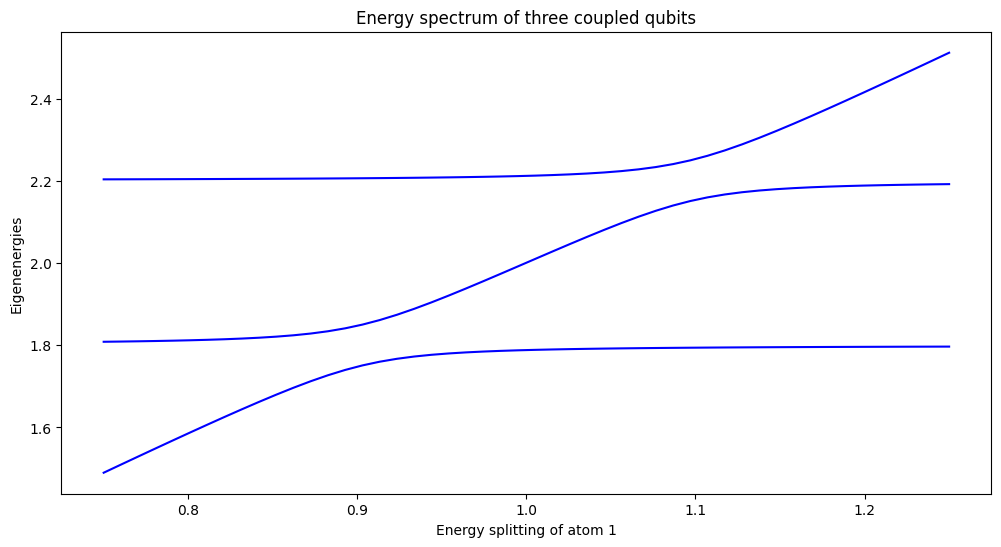

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

for n in [1, 2, 3]:     # we have up to 7(8)
    ax.plot(w1list / (2 * pi),
            (evals_mat[:,n] - evals_mat[:, 0]) / (2 * pi), "b")

# evals_mat[:, n] : nth energy level
# evals_mat[:, 0] : ground state energy
# En - E0 => Energy Gap or transition energy
# Divide by 2pie => convert: Angular frequency => normal frequency

ax.set_xlabel("Energy splitting of atom 1")
ax.set_ylabel("Eigenenergies")
ax.set_title("Energy spectrum of three coupled qubits");